**Script: Practice with package: Pyicon, using xarray**
- Author: Muxin Hu (muxin.hu@mpimet.mpg.de)
- Date created: 04/11/2025
- Late modified: 07/11/2025 

**Paths**
- the package is downloaded and installed in the directory: `/home/m/m301254/Download/pyicon`
- the aim is to be familiar with the pyicon package with the xarray


In [ ]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import pyicon as pyic
import cartopy.crs as ccrs
# from netCDF4 import Dataset
# import sys

----Start loading pyicon.
Loading default parameters from /home/m/m301254/Download/pyicon/pyicon/params_default.json.
----Start loading pyicon.
----Pyicon was loaded successfully.
----Pyicon was loaded successfully.


# Analysis on ICON-o test run
- for the ICON-o documentation, please go: https://icon-o.gitlab-pages.dkrz.de/icon-o-documentation/
- for the script running the icon-o, please find the section: Quickstart Tutorial + Running ICON-O
    - The current script reference can be visualised in: `/work/mh0033/m301254/proj_surfwave/icon-2025-04_2-public/icon-model/prepare.sh`
- The test runs for 10 years, with the results stored in: `/work/mh0033/m301254/proj_surfwave/icon-2025-04_2-public/icon-model/experiments/test20251029/`
- The test runs with the grid resolution as: icon_grid_0036_R02B04_O.nc

In [15]:
# Names and paths
run='test20251029'
gname='r2b4_oce_r0004'
lev='L40'

# directory paths
path_data = f'/work/mh0033/m301254/proj_surfwave/icon-2025-04_2-public/icon-model/experiments/{run}'
path_grid = f'/home/m/m301254/pyicon_data/grids/{gname}'
path_ckdtree= f'{path_grid}/ckdtree'                             # useful for large data interpolation

# file paths
fpath_fx = f'{path_grid}/{gname}_{lev}_fx.nc'
fpath_tgrid = f'{path_grid}/{gname}_tgrid.nc'
res = 'res1.00' # choose resolution for interplation between 1.00, 0.30, 0.10, 0.02
fpath_ckdtree= f'{path_ckdtree}/rectgrids/{gname}_{res}_180W-180E_90S-90N.nc'


## Specify dataset
- this is **different from using IcD = pyic.IconData()!!**, since the exact dataset is specified, instead of loading the whole time series

In [16]:
# specify dataset
ds_3d = xr.open_dataset(f'{path_data}/test20251029_P1M_3d_20090101T000000Z.nc')
ds_moc = xr.open_dataset(f'{path_data}/test20251029_P1M_moc_20090101T000000Z.nc')

In [27]:
ds_3d

<xarray.Dataset> Size: 518MB
Dimensions:                    (ncells: 15105, vertices: 3, ncells_2: 23207,
                                vertices_2: 4, time: 12, depth: 40, depth_2: 41)
Coordinates:
  * time                       (time) datetime64[ns] 96B 2009-01-01 ... 2009-...
  * depth                      (depth) float64 320B 6.0 17.0 ... 5.72e+03
  * depth_2                    (depth_2) float64 328B 0.0 12.0 ... 6.02e+03
    clon                       (ncells) float64 121kB ...
    clat                       (ncells) float64 121kB ...
    elon                       (ncells_2) float64 186kB ...
    elat                       (ncells_2) float64 186kB ...
Dimensions without coordinates: ncells, vertices, ncells_2, vertices_2
Data variables: (12/20)
    clon_bnds                  (ncells, vertices) float64 363kB ...
    clat_bnds                  (ncells, vertices) float64 363kB ...
    elon_bnds                  (ncells_2, vertices_2) float64 743kB ...
    elat_bnds                  (ncells_2, vertices_2) float64 743kB ...
    to                         (time, depth, ncells) float32 29MB ...
    so                         (time, depth, ncells) float32 29MB ...
    ...                         ...
    rhopot                     (time, depth, ncells) float32 29MB ...
    mass_flux                  (time, depth, ncells_2) float32 45MB ...
    heat_content_liquid_water  (time, depth, ncells) float32 29MB ...
    swrab                      (time, depth, ncells) float32 29MB ...
    rsdoabsorb                 (time, depth, ncells) float32 29MB ...
    tke                        (time, depth_2, ncells) float32 30MB ...
Attributes:
    CDI:                  Climate Data Interface version 2.5.2 (https://mpime...
    Conventions:          CF-1.6
    number_of_grid_used:  36
    grid_file_uri:        http://icon-downloads.mpimet.mpg.de/grids/public/mp...
    uuidOfHGrid:          5bd948e8-ac1a-11ea-a6b1-d317264fdca9
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    title:                ICON simulation
    source:               version: 2025.04-2; revision: icon-2025.04-2-public...
    history:              /work/mh0033/m301254/icon-model/bin/icon at 2025102...
    references:           see MPIM/DWD publications
    comment:              Muxin Hu (m301254) on l30472 (Linux 4.18.0-553.74.1...

In [26]:
ds_moc

<xarray.Dataset> Size: 1MB
Dimensions:            (time: 12, depth: 40, lat: 180, lon: 1)
Coordinates:
  * time               (time) datetime64[ns] 96B 2009-01-01 ... 2009-12-01
  * depth              (depth) float64 320B 6.0 17.0 27.0 ... 5.17e+03 5.72e+03
  * lat                (lat) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon                (lon) float64 8B 0.0
Data variables: (12/15)
    global_moc         (time, depth, lat, lon) float32 346kB ...
    atlantic_moc       (time, depth, lat, lon) float32 346kB ...
    pacific_moc        (time, depth, lat, lon) float32 346kB ...
    global_hfl         (time, lat, lon) float32 9kB ...
    atlantic_hfl       (time, lat, lon) float32 9kB ...
    pacific_hfl        (time, lat, lon) float32 9kB ...
    ...                 ...
    global_hfbasin     (time, lat, lon) float32 9kB ...
    atlantic_hfbasin   (time, lat, lon) float32 9kB ...
    pacific_hfbasin    (time, lat, lon) float32 9kB ...
    global_sltbasin    (time, lat, lon) float32 9kB ...
    atlantic_sltbasin  (time, lat, lon) float32 9kB ...
    pacific_sltbasin   (time, lat, lon) float32 9kB ...
Attributes:
    CDI:          Climate Data Interface version 2.5.2 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  Max Planck Institute for Meteorology/Deutscher Wetterdienst
    title:        ICON simulation
    source:       version: 2025.04-2; revision: icon-2025.04-2-public-0-g2894...
    history:      /work/mh0033/m301254/icon-model/bin/icon at 20251029 130204
    references:   see MPIM/DWD publications
    comment:      Muxin Hu (m301254) on l30472 (Linux 4.18.0-553.74.1.el8_10....

## Select data: *to* and *moc* at time = t0

In [78]:
# potential T at t0
to = ds_3d['to'].isel(time=0, depth=0)
to_3d = ds_3d['to'].isel(time=0)

# AMOC at t0 (depth, lat, lon)
amoc_3d = ds_moc['atlantic_moc'].isel(time=0)

## Derive means, max, shape

In [ ]:
to_clean = to.where(to!=0.)    # wherever to = 0.0 -> set to NaN; wherever to !=0.0 -> keep original
print(f'the global mean of potential T at {to_clean.time.values} at {to_clean.depth.values} depth: {np.nanmean(to_clean.values)}')
# or in a more simpler way
print(f'global mean of poten. T at 6 m depth: {to_clean.mean()}')

the global mean of potential T at 2009-01-01T00:00:00.000000000 at 6.0 depth: 18.287750244140625
global mean of poten. T at 6 m depth: <xarray.DataArray 'to' ()> Size: 4B
array(18.28775, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2009-01-01
    depth    float64 8B 6.0


In [ ]:
print(to_clean.shape)
print(to_3d.shape)

(15105,)
(40, 15105)


In [49]:
print(f'the maximum Atlantic meridional overturning (zonally averaged overturning) at \
{amoc_3d.time.values} is: {np.max(amoc_3d.values)/10**(9)} Sv')

the maximum Atlantic meridional overturning (zonally averaged overturning) at 2009-01-01T00:00:00.000000000 is: 18.8691349029541 Sv


In [79]:
print(amoc_3d.shape)

(40, 180, 1)


## For the 2D Potential T *'to(ncells)'*

### Interpolate 2D data *'to(ncells)'* to a regular grid
- Use the pyicon interp_to_rectgrid_xr function:
    - The path to the regular grid ckdtree file (fpath_ckdtree) needs to be specified. 
    - It decides which regular grid is taken but only those grids can be chosen which were calculated and saved externally.

In [62]:
# interpolation using the ckdtree file with specified resolution for the same grid in test run
# to is a unstructured file only in one time and one layer
toi = pyic.interp_to_rectgrid_xr(to_clean, fpath_ckdtree=fpath_ckdtree)

In [63]:
toi

<xarray.DataArray (lat: 180, lon: 360)> Size: 259kB
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [-1.79995  , -1.799958 , -1.799958 , ..., -1.79995  , -1.79995  ,
        -1.79995  ],
       [-1.79995  , -1.799958 , -1.799958 , ..., -1.79995  , -1.79995  ,
        -1.79995  ],
       [-1.799947 , -1.7999476, -1.7999476, ..., -1.799947 , -1.799947 ,
        -1.799947 ]], shape=(180, 360), dtype=float32)
Coordinates:
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 86.0 87.0 88.0 89.0
  * lon      (lon) float64 3kB -180.0 -179.0 -178.0 -177.0 ... 177.0 178.0 179.0
Attributes:
    standard_name:                sea_water_potential_temperature
    long_name:                    sea water potential temperature
    units:                        C
    code:                         255
    CDI_grid_type:                unstructured
    number_of_grid_in_reference:  1

#### Plotting with xarray

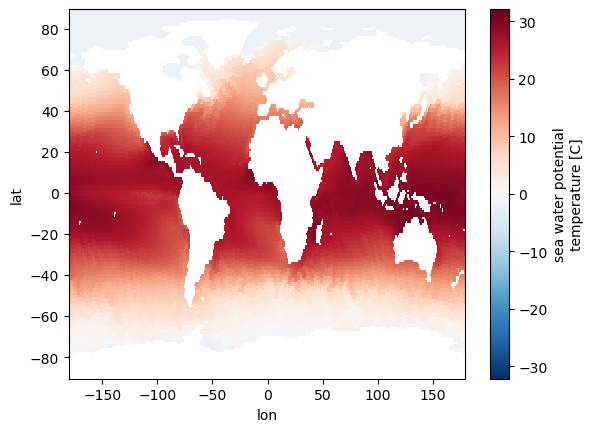

In [64]:
fig = plt.figure()
toi.plot()

#### Plotting with pyicon

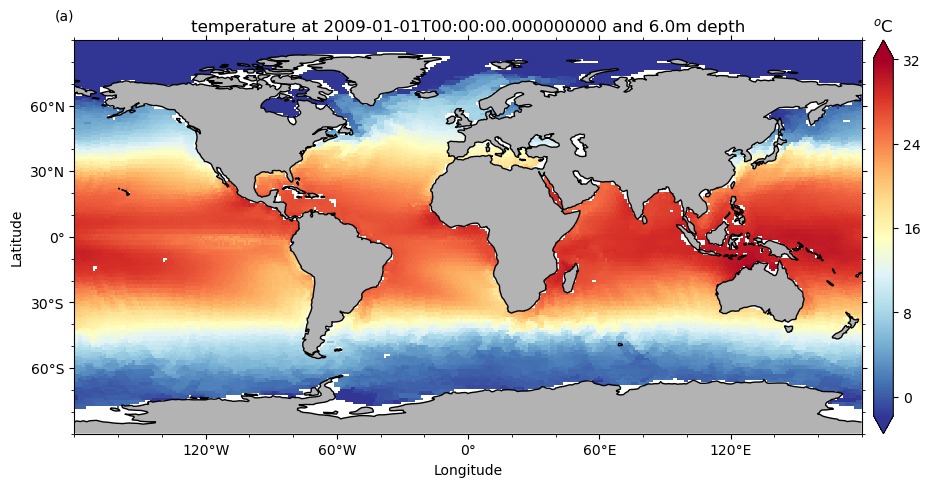

In [65]:
projection = ccrs.PlateCarree()
hca, hcb = pyic.arrange_axes(1,1, plot_cb= True, asp=0.5, 
                             fig_size_fac=2.5, projection=projection)
ii = -1
ii+=1; ax=hca[ii]; cax=hcb[ii]
pyic.shade(toi.lon, toi.lat, datai=toi, ax=ax, cax=cax, clim='auto')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('temperature at %s and %.1fm depth'%(to.time.values, to_clean.depth.values))
cax.set_title('$^o$C')

pyic.plot_settings(ax, template='global')

### Plotting a region on the original triangular grid
Specify region and derive triangulatino object using pyic.triangulation
- **pyic.triangulation**: builds a Matplotlib Triangulation object (a triangular mesh) from the ICON unstructured grid
- default: def triangulation(ds_tgrid, lon_reg=None, lat_reg=None,
                  do_mask_big_triangles=True, only_lon=True,
                  shift_to_zero_dateline=False):
    - ds_grid: ICON's t-grid dataset, contains vertex and cell geometry
    - lon_reg, lat_reg: optional region bounds
    - do_mask_big_triangles: Whether to mast abnormallt large triangles (occurs near boundaries and poles)
    - only_lon: internal flag controlling how big triangles are detected
    - shift_to_zero_dateline: if True, moves all longitudes from [-180,180] to [0,360]

In [73]:
# specify the region bounds in rectangular grid
lon_reg = [-60, 5]
lat_reg = [30, 75]

# specify the triangular grid information: fpath_tgrid
ds_tg = xr.open_dataset(fpath_tgrid)

# ind_reg is a Boolean array marking which cells are inside; 
# Tri: Triangulation Object; Tri.x, Tri.y -> coordinates of each vertex
ind_reg, Tri = pyic.triangulation(ds_tg, lon_reg=lon_reg, lat_reg=lat_reg)

In [74]:
# use ind_reg to select the data to plot/use
to_reg = to_clean.isel(ncells=ind_reg)

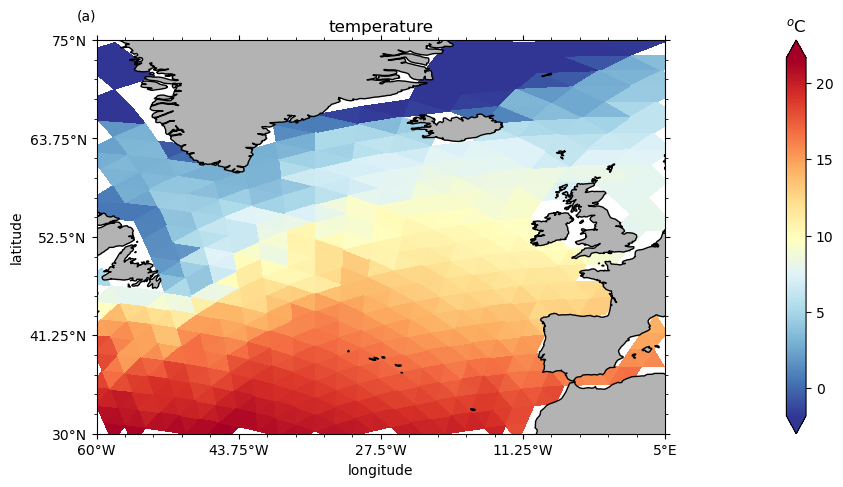

In [75]:
hca, hcb = pyic.arrange_axes(1,1, plot_cb=True, asp=0.5, 
                             fig_size_fac=2.5, projection=projection)
ii=-1
ii+=1; ax=hca[ii]; cax=hcb[ii]
pyic.shade(Tri, to_reg, ax=ax, cax=cax)
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
ax.set_title('temperature')
cax.set_title('$^o$C')

pyic.plot_settings(ax, xlim=lon_reg, ylim=lat_reg)

## For the 3D AMOC (Meridional Overturning streamfunction)

### use regular print

In [88]:
# aiming at (depth, latitude) 
amoc_2d = amoc_3d.isel(lon=0)

# convert unit from kg/s to Sv
amoc_2d = amoc_2d / 10**(9)

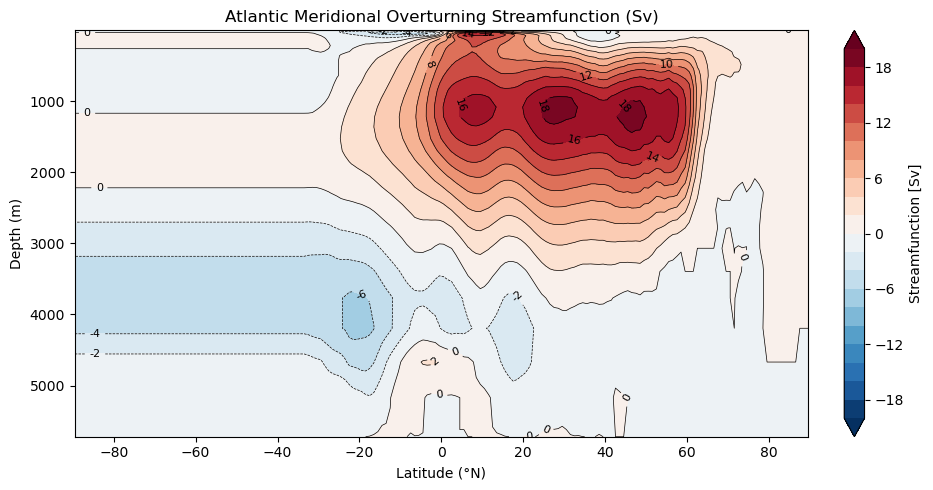

In [95]:
# use matplotlib
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1,1,1)

# coutour filling
cf = plt.contourf(amoc_2d['lat'], amoc_2d['depth'],amoc_2d.values,
                  levels=np.linspace(-20,20,21),
                  cmap='RdBu_r',
                  extend='both')

# optional: coutour lines
cs = plt.contour(amoc_2d['lat'], amoc_2d['depth'], amoc_2d.values,
                 levels=np.arange(-20, 21, 2),
                 colors='k', linewidths=0.5)
plt.clabel(cs, fmt='%d', fontsize=8)   # add values?

ax.invert_yaxis()

# Labels and title
plt.title('Atlantic Meridional Overturning Streamfunction (Sv)')
plt.xlabel('Latitude (°N)')
plt.ylabel('Depth (m)')

# Add colorbar
cb = plt.colorbar(cf, ax=ax, orientation='vertical', label='Streamfunction [Sv]', pad=0.04)

plt.tight_layout()
plt.show()

## For a regional average density profile

In [121]:
# full space data in shape of (time, depth, ncells)
rhopot_all = ds_3d['rhopot']
# interested in the winter time (JFM) average
rhopot_JFM_ave = rhopot_all.sel(time=rhopot_all.time.dt.month.isin([1,2,3])).mean(dim='time')

### need to use original triangular grid for the region mask

In [118]:
# specify the region bounds in rectangular grid
lon_reg = [-60, -30]
lat_reg = [50, 60]

# specify the triangular grid information: fpath_tgrid
ds_tg = xr.open_dataset(fpath_tgrid)

# ind_reg is a Boolean array marking which cells are inside; 
# Tri: Triangulation Object; Tri.x, Tri.y -> coordinates of each vertex
ind_reg, Tri = pyic.triangulation(ds_tg, lon_reg=lon_reg, lat_reg=lat_reg)

In [150]:
ds_tg

<xarray.Dataset> Size: 15MB
Dimensions:                         (cell: 15105, nv: 3, edge: 23207, no: 4,
                                     vertex: 8067, ne: 6, nc: 2,
                                     max_stored_decompositions: 4, two_grf: 2,
                                     cell_grf: 14, max_chdom: 1, edge_grf: 24,
                                     vert_grf: 13)
Coordinates:
    clon                            (cell) float64 121kB 1.206 1.274 ... 1.327
    clat                            (cell) float64 121kB 1.27 1.301 ... -0.7828
    elon                            (edge) float64 186kB ...
    elat                            (edge) float64 186kB ...
    vlon                            (vertex) float64 65kB 1.274 1.211 ... 1.354
    vlat                            (vertex) float64 65kB 1.279 1.248 ... -0.794
Dimensions without coordinates: cell, nv, edge, no, vertex, ne, nc,
                                max_stored_decompositions, two_grf, cell_grf,
                                max_chdom, edge_grf, vert_grf
Data variables: (12/91)
    clon_bnds                       (cell, nv) float64 363kB ...
    clat_bnds                       (cell, nv) float64 363kB ...
    elon_bnds                       (edge, no) float64 743kB ...
    elat_bnds                       (edge, no) float64 743kB ...
    vlon_bnds                       (vertex, ne) float64 387kB ...
    vlat_bnds                       (vertex, ne) float64 387kB ...
    ...                              ...
    edge_dual_normal_cartesian_x    (edge) float64 186kB ...
    edge_dual_normal_cartesian_y    (edge) float64 186kB ...
    edge_dual_normal_cartesian_z    (edge) float64 186kB ...
    cell_circumcenter_cartesian_x   (cell) float64 121kB ...
    cell_circumcenter_cartesian_y   (cell) float64 121kB ...
    cell_circumcenter_cartesian_z   (cell) float64 121kB ...
Attributes: (12/47)
    CDI:                      Climate Data Interface version 1.9.8 (https://m...
    Conventions:              CF-1.6
    history:                  Wed Jul 15 13:53:13 2020: cdo replace icon_grid...
    number_of_grid_used:      36
    grid_file_uri:            http://icon-downloads.mpimet.mpg.de/grids/publi...
    uuidOfHGrid:              5bd948e8-ac1a-11ea-a6b1-d317264fdca9
    ...                       ...
    topography:               modified SRTM30 as in0014 but with improved top...
    symmetry:                 along equator
    subcentre:                0
    ICON_grid_file_uri:       http://icon-downloads.mpimet.mpg.de/grids/publi...
    NCO:                      netCDF Operators version 4.7.5 (Homepage = http...
    CDO:                      Climate Data Operators version 1.9.8 (https://m...

In [122]:
# then, select the rhopot in the indice which is inside the mask
rhopot_JFM_ave_reg = rhopot_JFM_ave.isel(ncells=ind_reg)

### Regional mean vertical profile, with/without weighted average

In [133]:
# plot the average profile?
rhopot_JFM_ave_profile = rhopot_JFM_ave_reg.mean(dim='ncells')

# if apply the weight of the cell
cell_area = ds_tg['cell_area'].rename({'cell': 'ncells'})
cell_area_reg = cell_area.isel(ncells=ind_reg)

weights = cell_area_reg / cell_area_reg.sum()
rhopot_JFM_ave_weighted_profile = (rhopot_JFM_ave_reg * weights).sum(dim='ncells')

In [134]:
rhopot_JFM_ave_weighted_profile

<xarray.DataArray (depth: 40)> Size: 320B
array([988.81065304, 988.80745953, 988.80711572, 988.80691787,
       988.80681011, 988.80684742, 988.80760214, 988.81124769,
       988.81947427, 988.83109253, 988.84328513, 988.85552133,
       975.87378884, 924.32843726, 924.34078318, 885.50466568,
       859.63513604, 859.65012304, 859.66544265, 859.68250928,
       859.69590832, 859.70477927, 859.7113889 , 834.00712911,
       834.01262027, 834.01566897, 821.1852374 , 821.18874782,
       808.37917139, 782.69925113, 782.70171526, 731.41538596,
       603.31727036, 474.41366057, 281.51226476, 127.96633375,
        38.23930749,   0.        ,   0.        ,   0.        ])
Coordinates:
  * depth    (depth) float64 320B 6.0 17.0 27.0 ... 4.67e+03 5.17e+03 5.72e+03

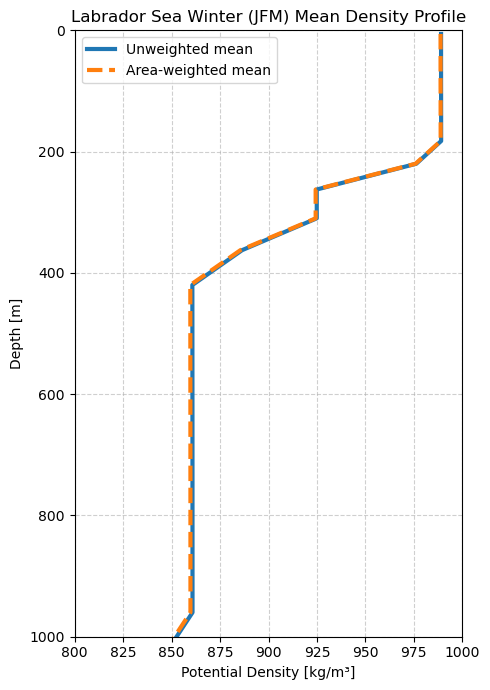

In [149]:
plt.figure(figsize=(5, 7))

plt.plot(rhopot_JFM_ave_profile, rhopot_JFM_ave_profile.depth, label='Unweighted mean', color='tab:blue', linewidth=3)
plt.plot(rhopot_JFM_ave_weighted_profile, rhopot_JFM_ave_weighted_profile.depth, label='Area-weighted mean', color='tab:orange', linewidth=3, linestyle='--')

plt.ylim(1000,0)
plt.xlim(800, 1000)

# plt.gca().invert_yaxis()  # Depth increases downward
plt.xlabel('Potential Density [kg/m³]')
plt.ylabel('Depth [m]')
plt.title('Labrador Sea Winter (JFM) Mean Density Profile')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()